In [1]:
import logging
from dscribe.descriptors import SOAP
from ase.build import molecule
from models.descriptors import SOAPDescriptor
from models.gp_model import AtomicGaussianProcess
from md.compute_forces_fd import compute_forces_fd
import numpy as np
from dft.run_dft import run_dft
from ase.calculators.emt import EMT
from md.dynamics import run_velocity_verlet_md

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)

In [2]:
atoms = molecule("CH4")
atoms.center(vacuum=5.0)

atoms

Atoms(symbols='CH4', pbc=False, cell=[11.258236, 11.258236, 11.258236])

In [3]:
print("DScribe works")

DScribe works


In [4]:

descriptor = SOAPDescriptor(species=["C", "H"])
gp_model = AtomicGaussianProcess()

In [5]:
from dft.run_dft import run_dft
from ase.calculators.emt import EMT

E, F = run_dft(atoms, EMT())
print("Energy is: ", E)
print("Foreces are: ")
print(F)


Energy is:  1.9905788935393591
Foreces are: 
[[ 0.00000000e+00  0.00000000e+00  8.88178420e-16]
 [ 1.10659849e+00  1.10659849e+00  1.10659849e+00]
 [-1.10659849e+00 -1.10659849e+00  1.10659849e+00]
 [ 1.10659849e+00 -1.10659849e+00 -1.10659849e+00]
 [-1.10659849e+00  1.10659849e+00 -1.10659849e+00]]


In [6]:
# make a tiny local training set
dataset_structures = [atoms]

for shift in [0.03, -0.03, 0.06, -0.06]:
    a = atoms.copy()
    a.positions[1, 0] += shift
    dataset_structures.append(a)

dataset_energies = []
for a in dataset_structures:
    E, _ = run_dft(a, EMT())
    dataset_energies.append(E)

X_list = [descriptor.create(a) for a in dataset_structures]
gp_model.fit(X_list, dataset_energies)

F_gp = compute_forces_fd(atoms, descriptor, gp_model)
print("The norm of the forces is:", np.linalg.norm(F_gp))
print("THe computed forces are:")
print(F_gp)

The norm of the forces is: 1.9244880591496731
THe computed forces are:
[[ 6.42819131e-10 -6.42819131e-10  4.13002965e-10]
 [ 5.55551851e-01  5.55551850e-01  5.55551849e-01]
 [-5.55551850e-01 -5.55551850e-01  5.55551849e-01]
 [ 5.55551850e-01 -5.55551850e-01 -5.55551849e-01]
 [-5.55551849e-01  5.55551849e-01 -5.55551849e-01]]


In [ ]:
from md.dynamics import run_velocity_verlet_md

traj, energies = run_velocity_verlet_md(
    atoms,
    descriptor,
    gp_model,
    timestep=0.1,
    n_steps=5,
)


print("there are: ", len(traj), " structures in trajectory")
print("the system energies are: " ,energies)

In [ ]:
from md.compute_forces_fd import compute_forces_fd
import numpy as np

F = compute_forces_fd(atoms, descriptor, gp_model)
print("Force norm:", np.linalg.norm(F))
print("Max force component:", np.max(np.abs(F)))

In [ ]:

print("The generation infomration of the run")

for i, frame in enumerate(traj):
    F = compute_forces_fd(frame, descriptor, gp_model)
    print(i, "E=", energies[i], "disp=", np.linalg.norm(frame.positions - traj[0].positions),
          "F_norm=", np.linalg.norm(F), "maxF=", np.max(np.abs(F)))

2026-04-27 06:27:52,727 - active_learning.gp_cycle - INFO - ----- Active Learning Summary -----
2026-04-27 06:27:52,728 - active_learning.gp_cycle - INFO - Mode: batch
2026-04-27 06:27:52,728 - active_learning.gp_cycle - INFO - Selection strategy: top_uncertainty
2026-04-27 06:27:52,729 - active_learning.gp_cycle - INFO - Total structures: 6
2026-04-27 06:27:52,729 - active_learning.gp_cycle - INFO - Selected for DFT: 3
2026-04-27 06:27:52,730 - active_learning.gp_cycle - INFO - Max uncertainty: 1.9536e-01
2026-04-27 06:27:52,730 - active_learning.gp_cycle - INFO - Mean uncertainty: 1.2853e-01
2026-04-27 06:27:52,731 - active_learning.gp_cycle - INFO - Selected indices: [5 4 3]
2026-04-27 06:27:52,826 - active_learning.gp_cycle - INFO - ----- Active Learning Summary -----
2026-04-27 06:27:52,826 - active_learning.gp_cycle - INFO - Mode: batch
2026-04-27 06:27:52,826 - active_learning.gp_cycle - INFO - Selection strategy: top_uncertainty
2026-04-27 06:27:52,827 - active_learning.gp_cycl


Cycle 0
Energies: [1.9905789  1.9854001  1.94940513 1.99339541 1.99890683 1.99891214]
Selected indices: [5 4 3]
Max uncertainty: 0.19535635443260052

Cycle 1
Energies: [1.79258585 1.93738314 1.93739021 1.93739021 1.93739021 1.93739021]
Selected indices: [3 4 2]
Max uncertainty: 0.37397480347019435

Cycle 2


2026-04-27 06:27:52,943 - active_learning.gp_cycle - INFO - ----- Active Learning Summary -----
2026-04-27 06:27:52,943 - active_learning.gp_cycle - INFO - Mode: batch
2026-04-27 06:27:52,943 - active_learning.gp_cycle - INFO - Selection strategy: top_uncertainty
2026-04-27 06:27:52,944 - active_learning.gp_cycle - INFO - Total structures: 6
2026-04-27 06:27:52,944 - active_learning.gp_cycle - INFO - Selected for DFT: 3
2026-04-27 06:27:52,945 - active_learning.gp_cycle - INFO - Max uncertainty: 4.3109e-01
2026-04-27 06:27:52,945 - active_learning.gp_cycle - INFO - Mean uncertainty: 4.3109e-01
2026-04-27 06:27:52,949 - active_learning.gp_cycle - INFO - Selected indices: [5 3 2]


Energies: [1.89450267 1.89451523 1.89451523 1.89451523 1.89451523 1.89451523]
Selected indices: [5 3 2]
Max uncertainty: 0.43108503615604843


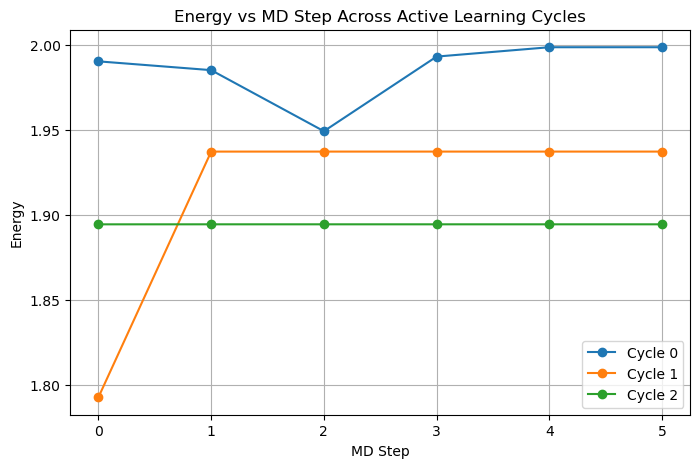

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ase.calculators.emt import EMT
from active_learning.gp_cycle import run_gp_active_learning_cycle
from md.dynamics import run_velocity_verlet_md

# --- settings ---
n_cycles = 3
md_steps = 5
timestep = 0.05

uncertainty_threshold = 0.01
max_dft_calls = 3

current_atoms = atoms.copy()

plt.figure(figsize=(8,5))

for cycle in range(n_cycles):
    print("\n==============================")
    print(f"Cycle {cycle}")
    print("==============================")

    # --- run MD ---
    traj, energies = run_velocity_verlet_md(
        current_atoms,
        descriptor,
        gp_model,
        timestep=timestep,
        n_steps=md_steps,
    )

    steps = np.arange(len(energies))

    print("Energies:", energies)

    # --- plot energies ---
    plt.plot(steps, energies, marker='o', label=f"Cycle {cycle}")

    # --- active learning ---
    results = run_gp_active_learning_cycle(
        structures=traj,
        descriptor=descriptor,
        gp_model=gp_model,
        calculator=EMT(),
        uncertainty_threshold=uncertainty_threshold,
        max_dft_calls=max_dft_calls,
        mode="batch",
        selection_strategy="top_uncertainty",
    )

    selected_structures = results["selected_structures"]
    selected_energies = results["dft_energies"]

    print("Selected indices:", results["selected_indices"])
    print("Max uncertainty:", results["gp_uncertainties"].max())

    # --- update dataset ---
    dataset_structures.extend(selected_structures)
    dataset_energies.extend(selected_energies)

    # --- retrain GP ---
    X_list = [descriptor.create(a) for a in dataset_structures]
    gp_model.fit(X_list, dataset_energies)

    # --- advance system ---
    current_atoms = traj[-1].copy()

# --- finalize plot ---
plt.xlabel("MD Step")
plt.ylabel("Energy")
plt.title("Energy vs MD Step Across Active Learning Cycles")
plt.legend()
plt.grid(True)
plt.show()